epoch    0 | loss 4.22957
epoch  300 | loss 0.03719
epoch  600 | loss 0.02141
epoch  900 | loss 0.01346
epoch 1200 | loss 0.00860
epoch 1500 | loss 0.00558
epoch 1800 | loss 0.00382
epoch 2100 | loss 0.00278
epoch 2400 | loss 0.00214
epoch 2700 | loss 0.00171


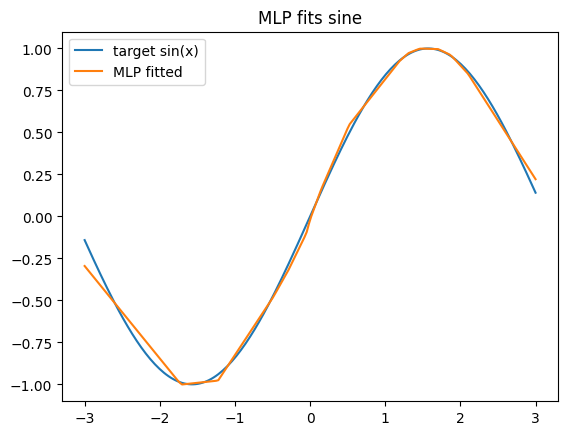

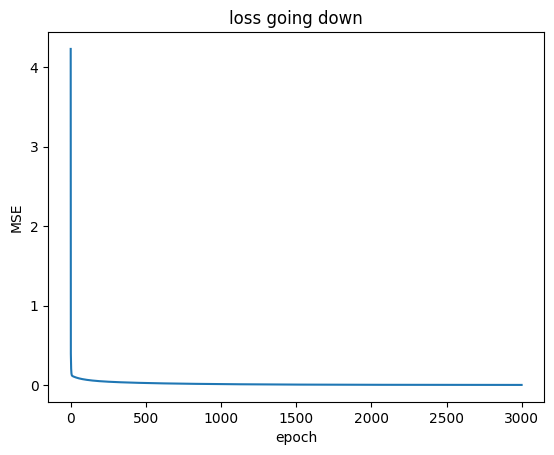

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def relu(z):
    return np.maximum(0, z)

# ---------- 数据：拟合 sin ----------
np.random.seed(0)
X = np.linspace(-3, 3, 200).reshape(-1, 1)   # (200,1)
y = np.sin(X)                                 # (200,1)
n = X.shape[0]

# ---------- 初始化参数 ----------
d_in, d_hidden, d_out = 1, 32, 1
W1 = np.random.randn(d_in, d_hidden) * 0.5    # (1,32)
b1 = np.zeros((1, d_hidden))                  # (1,32)
W2 = np.random.randn(d_hidden, d_out) * 0.5   # (32,1)
b2 = np.zeros((1, d_out))                     # (1,1)

lr = 0.02
epochs = 3000
loss_history = []

for epoch in range(epochs):
    # ===== 前向传播 =====
    z1 = X @ W1 + b1      # (200,32)
    a1 = relu(z1)         # (200,32)
    z2 = a1 @ W2 + b2     # (200,1) = ŷ

    # ===== 损失 (MSE) =====
    loss = np.mean((z2 - y) ** 2)
    loss_history.append(loss)

    # ===== 反向传播 =====
    dz2 = (2 / n) * (z2 - y)                    # (200,1)
    dW2 = a1.T @ dz2                            # (32,1)
    db2 = np.sum(dz2, axis=0, keepdims=True)    # (1,1)

    da1 = dz2 @ W2.T                            # (200,32)
    dz1 = da1 * (z1 > 0)                        # (200,32) ReLU 反向
    dW1 = X.T @ dz1                             # (1,32)
    db1 = np.sum(dz1, axis=0, keepdims=True)    # (1,32)

    # ===== 梯度下降更新 =====
    W1 -= lr * dW1
    b1 -= lr * db1
    W2 -= lr * dW2
    b2 -= lr * db2

    if epoch % 300 == 0:
        print(f"epoch {epoch:4d} | loss {loss:.5f}")

# ---------- 看拟合结果 ----------
z1 = X @ W1 + b1; a1 = relu(z1); y_pred = a1 @ W2 + b2
plt.plot(X, y, label="target sin(x)")
plt.plot(X, y_pred, label="MLP fitted")
plt.legend(); plt.title("MLP fits sine"); plt.show()

# ---------- 看损失曲线 ----------
plt.plot(loss_history); plt.xlabel("epoch"); plt.ylabel("MSE")
plt.title("loss going down"); plt.show()